In [1]:
import os
import numpy as np

os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  #hide GPUs from tf so it doesnt try to use them and get memory errors
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D 

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input, LeakyReLU, Dropout

from parameters import *

## Build hypermodel matching the improved training notebook
This must match the `build_hypermodel` in `ml_01_train_keras-3_improved.ipynb` exactly,
so that the Keras Tuner can reload the saved trial data.

In [2]:
# Load the multi-head dimensions (needed for one-hot encoding path)
# These are the same .npy files the training notebook loads
try:
    headers_cont = np.load("y_columns_continuous.npy", allow_pickle=True).astype(str).tolist()
    headers_fc   = np.load("y_columns_fingers.npy",   allow_pickle=True).astype(str).tolist()
    n_continuous  = len(headers_cont)
    n_fc_classes  = len(headers_fc)
    print(f"Multi-head: {n_continuous} continuous outputs, {n_fc_classes} finger_count classes")
except FileNotFoundError:
    print("Could not find y_columns_continuous.npy / y_columns_fingers.npy")
    print("Will fall back to single-head model for analysis")
    n_continuous = None
    n_fc_classes = None

# We also need to know the input dimension from the test data
def load_scaled_split(kind, split):
    return np.load(f"{DATA_DIR}/npy/{split}_{kind}_encoding_scaled.npy", allow_pickle=True)

if 'one hot' in ENCODING_TYPE or 'Try Both' in ENCODING_TYPE:
    X_test = load_scaled_split('one_hot', 'x_test')
elif 'Linear' in ENCODING_TYPE:
    X_test = load_scaled_split('linear', 'x_test')
    
y_train = load_scaled_split('one_hot' if 'one hot' in ENCODING_TYPE else 'linear', 'y_train')

input_dim = X_test.shape[1]
print(f"Input dimension: {input_dim}")
print(f"Output dimension: {y_train.shape[1]}")

steps_per_epoch = int(np.ceil(301 / TRAIN_BATCH_SIZE))  # approximate from training notebook
LR_DECAY_STEPS_local = steps_per_epoch * 20

Multi-head: 3 continuous outputs, 10 finger_count classes
Input dimension: 6
Output dimension: 13


In [3]:
def build_hypermodel(hp):
    """
    This MUST match the build_hypermodel in ml_01_train_keras-3_improved.ipynb
    exactly, or the tuner won't be able to reload the trial data.
    """
    tf.keras.backend.clear_session()
    import gc; gc.collect()
    
    # Variable depth (1-5 layers)
    n_layers = hp.Int('n_layers', min_value=1, max_value=5, default=3)
    neurons_per_layer = [hp.Int(f'neurons_{i}', min_value=32, max_value=512, step=32) for i in range(n_layers)]
    
    # Wider regularization search
    dropout_rate = hp.Float('dropout_rate', 0.0, 0.4, step=0.05)
    l2_reg = hp.Float('l2_reg', 1e-5, 1e-2, sampling='LOG', default=1e-4)
    
    # Learning rate
    lr_initial = hp.Float('learning_rate', 1e-4, 3e-3, sampling='LOG', default=5e-4)
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=lr_initial,
        decay_steps=LR_DECAY_STEPS,
        decay_rate=LR_DECAY_RATE,
        staircase=LR_STAIRCASE
    )
    
    # Optional Batch Normalization
    use_batchnorm = hp.Boolean('use_batchnorm', default=True)
    
    if 'one hot' in ENCODING_TYPE and n_continuous is not None:
        fc_loss_weight = hp.Float('fc_loss_weight', 0.1, 10.0, sampling='LOG', default=1.0)
        
        inp = Input(shape=(input_dim,), name='input1')
        x = inp
        for i, n_units in enumerate(neurons_per_layer):
            x = Dense(n_units, name=f'fc{i}', kernel_initializer='he_normal',
                      kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
            if use_batchnorm:
                x = tf.keras.layers.BatchNormalization(name=f'bn{i}')(x)
            x = LeakyReLU(negative_slope=0.01, name=f'leaky_relu{i}')(x)
            x = Dropout(rate=dropout_rate, name=f'dropout{i}')(x)
        
        continuous_out = Dense(n_continuous, activation='linear', name='continuous',
                               kernel_initializer='he_normal')(x)
        fingers_out = Dense(n_fc_classes, activation='softmax', name='fingers',
                            kernel_initializer='he_normal', dtype='float32')(x)
        
        model = Model(inputs=inp, outputs=[continuous_out, fingers_out])
        model.compile(
            optimizer=tf.optimizers.Adam(learning_rate=lr_schedule),
            loss={'continuous': TRAIN_LOSS, 'fingers': 'categorical_crossentropy'},
            loss_weights={'continuous': 1.0, 'fingers': fc_loss_weight},
            metrics={'continuous': [TRAIN_LOSS], 'fingers': ['accuracy']}
        )
    else:
        model = Sequential()
        model.add(Input(shape=(input_dim,), name='input1'))
        for i, n_units in enumerate(neurons_per_layer):
            model.add(Dense(n_units, name=f'fc{i}', kernel_initializer='he_normal',
                            kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
            if use_batchnorm:
                model.add(tf.keras.layers.BatchNormalization(name=f'bn{i}'))
            model.add(LeakyReLU(negative_slope=0.01, name=f'leaky_relu{i}'))
            model.add(Dropout(rate=dropout_rate, name=f'dropout{i}'))
        model.add(Dense(y_train.shape[1], name='output', kernel_initializer='he_normal'))
        model.compile(optimizer=tf.optimizers.Adam(learning_rate=lr_schedule), 
                      loss=TRAIN_LOSS, metrics=[TRAIN_LOSS])
    return model

In [4]:
# Load the tuner results from the IMPROVED notebook's directory
from keras_tuner import BayesianOptimization

tuner = BayesianOptimization(
    build_hypermodel,
    objective='val_loss',
    max_trials=KERAS_TUNER_TRIALS,
    executions_per_trial=2,
    directory=KERAS_DIR + '/hyper_tuning_v2',
    project_name='mlp_tuning_bayesian',
)

tuner.reload()
print(f"Loaded {len(tuner.oracle.trials)} trials")

Reloading Tuner from keras/hyper_tuning_v2/mlp_tuning_bayesian/tuner0.json
Loaded 14 trials


In [5]:
# Extract the trials, accounting for variable-depth architecture
all_trials = tuner.oracle.trials

results = []
for trial_id, trial in all_trials.items():
    trial_data = dict(trial.hyperparameters.values)  # make a copy
    
    # Extract best val_loss
    if 'val_loss' in trial.metrics.metrics:
        val_loss_history = trial.metrics.get_history('val_loss')
        trial_data['val_loss'] = min([obs.value[0] for obs in val_loss_history if obs.value])
    else:
        trial_data['val_loss'] = None

    # Calculate total neurons (variable depth now!)
    n_layers = trial_data.get('n_layers', 5)  # fallback for old trials
    total_neurons = sum(trial_data.get(f'neurons_{i}', 0) for i in range(n_layers))
    trial_data['total_neurons'] = total_neurons
    trial_data['n_layers_actual'] = n_layers
    trial_data['trial_id'] = trial_id
    results.append(trial_data)

df = pd.DataFrame(results)
df = df.dropna(subset=['val_loss'])

print(f"Total completed trials: {len(df)}")
print(f"\nBest 5 trials by val_loss:")
print(df.nsmallest(5, 'val_loss')[['trial_id', 'n_layers', 'total_neurons', 'dropout_rate', 
                                     'l2_reg', 'learning_rate', 'use_batchnorm', 'val_loss']].to_string(index=False))

Total completed trials: 5

Best 5 trials by val_loss:
trial_id  n_layers  total_neurons  dropout_rate   l2_reg  learning_rate  use_batchnorm  val_loss
     007         1            352          0.10 0.008794       0.001194          False  0.901791
     001         1            416          0.05 0.000017       0.000105           True  1.419036
     002         1            160          0.00 0.000090       0.001153          False  2.238354
     010         4           1152          0.00 0.000514       0.000225          False  2.532378
     005         3            800          0.20 0.008409       0.000275          False  3.803294


val_loss dtype: float64


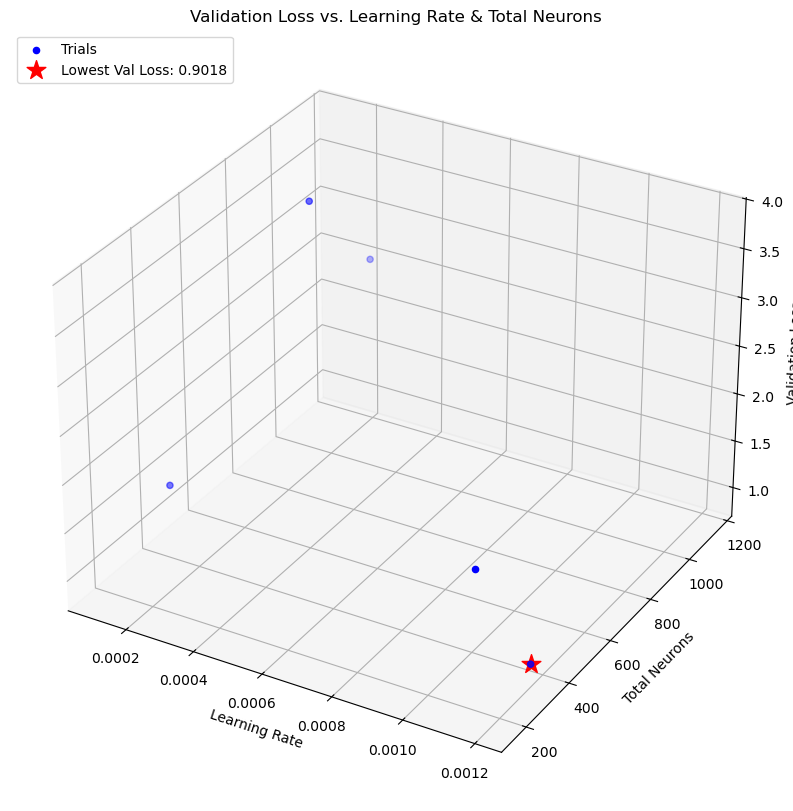

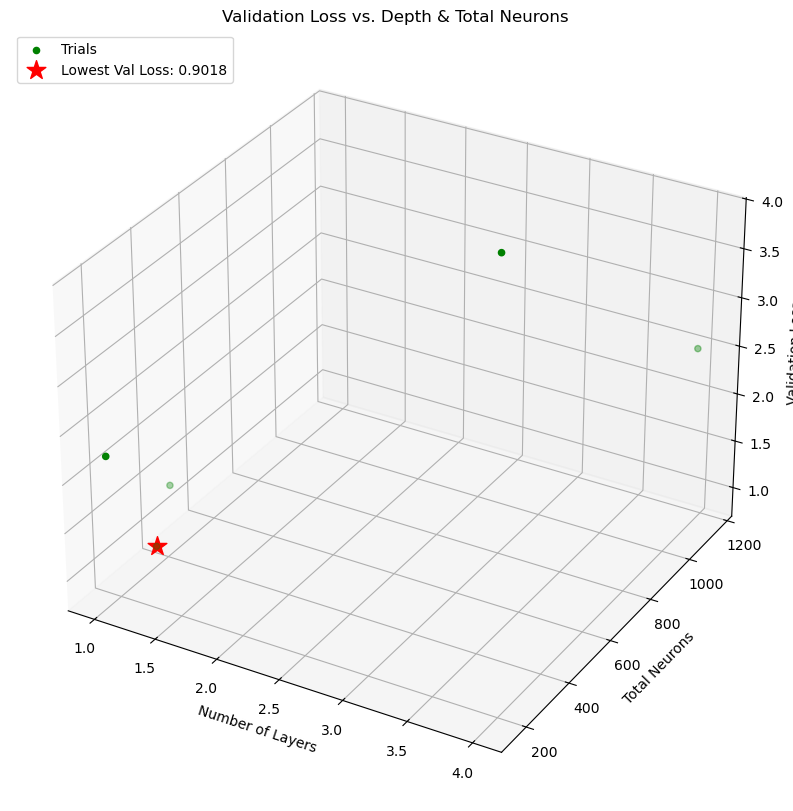

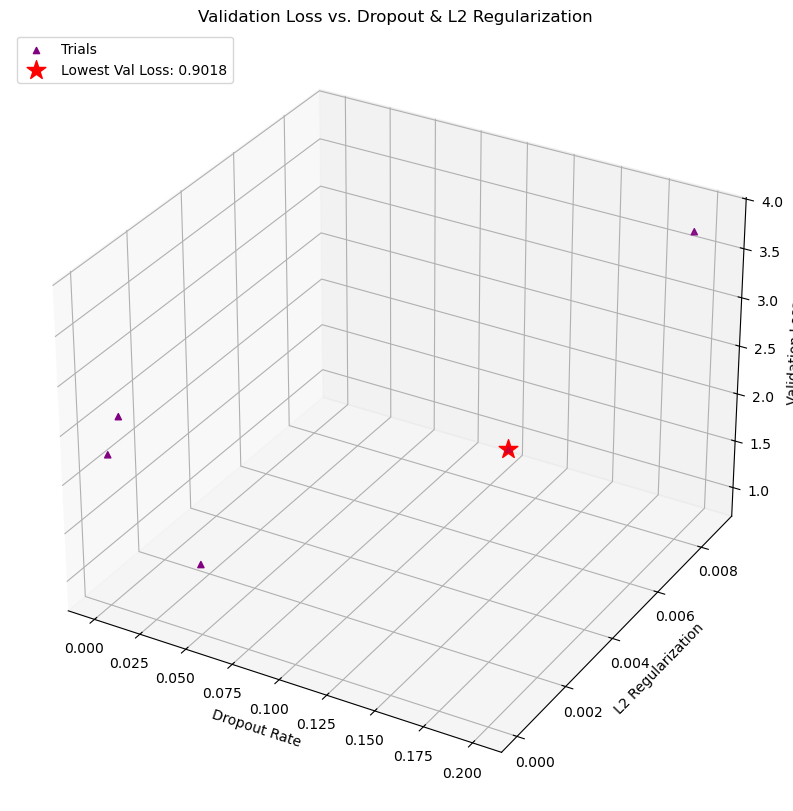

/tmp/ipykernel_3808803/4170221169.py:94: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


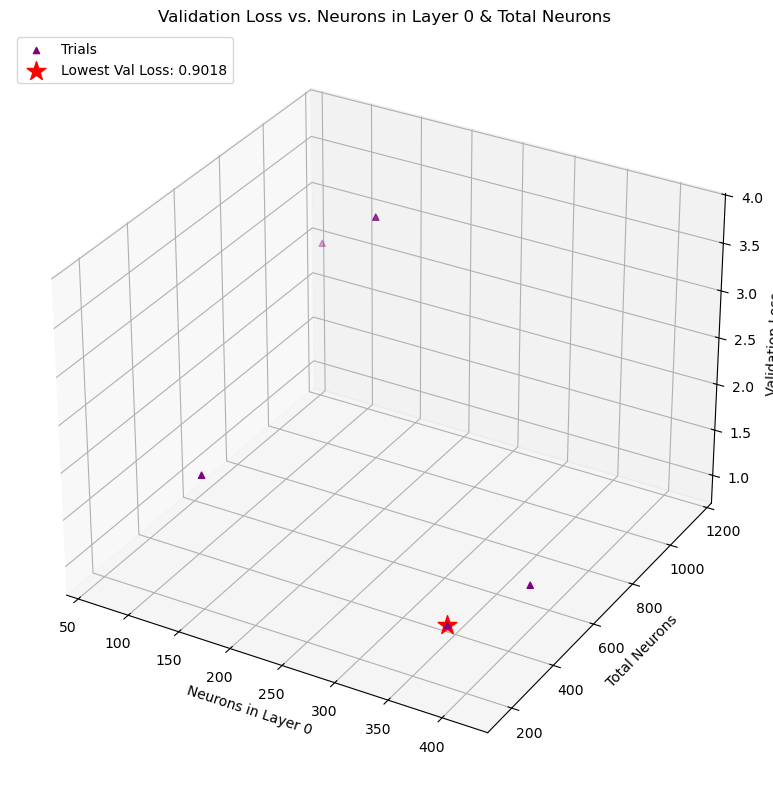

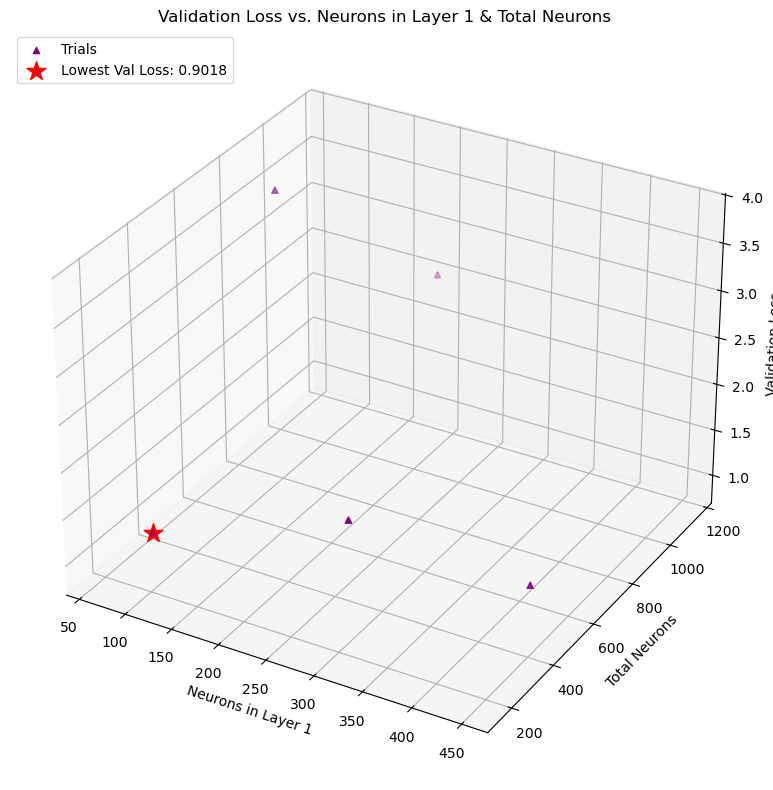

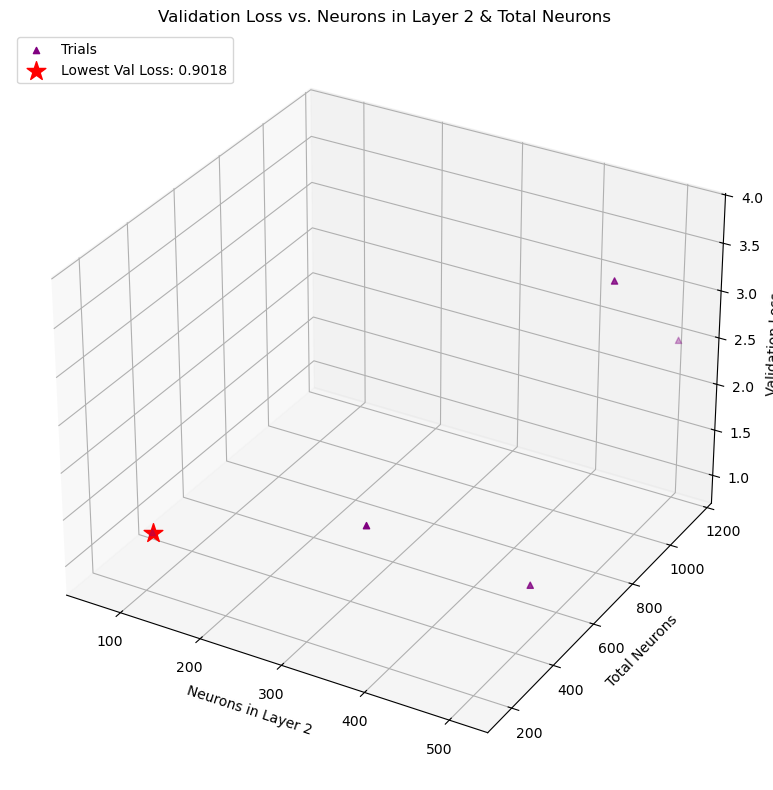

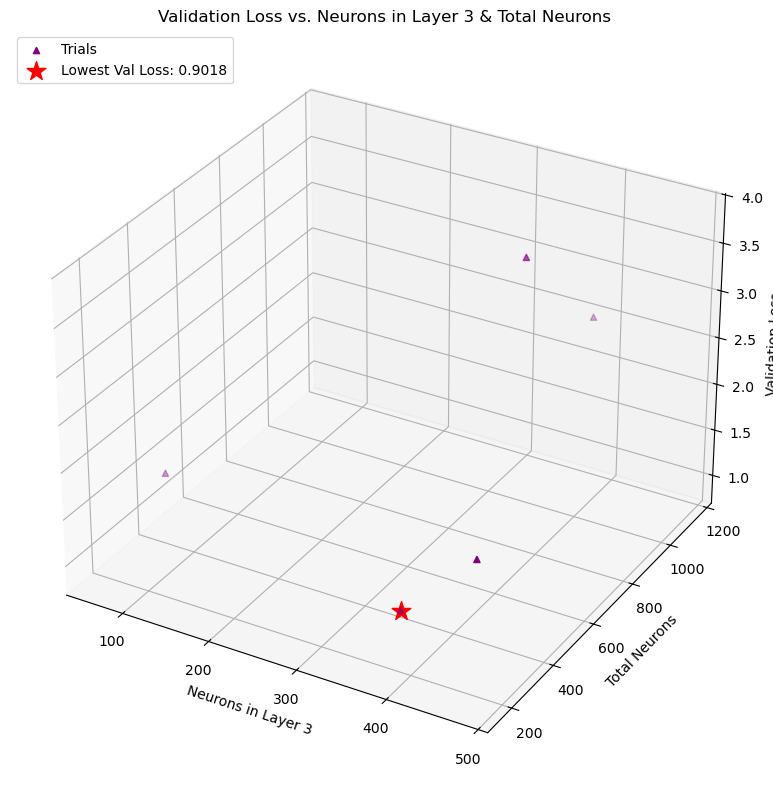

In [6]:
os.makedirs('plots', exist_ok=True)
os.makedirs('plots/hypertuner_search_metrics', exist_ok=True)

# Confirm all values in 'val_loss' are numeric
print("val_loss dtype:", df['val_loss'].dtype)

filtered_df = df[df['val_loss'].notna()].copy()

min_val_loss_index = df['val_loss'].idxmin()
min_val_loss_point = df.loc[min_val_loss_index]
min_loss = round(filtered_df.loc[filtered_df['val_loss'].idxmin()]['val_loss'], 4)

# --- 3D Plot: val_loss vs learning_rate vs total_neurons ---
fig = plt.figure(figsize=(10, 8), constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['learning_rate'], df['total_neurons'], df['val_loss'], c='blue', marker='o', label='Trials')
ax.scatter(
    min_val_loss_point['learning_rate'], 
    min_val_loss_point['total_neurons'], 
    min_val_loss_point['val_loss'], 
    c='red', marker='*', s=200, label=f'Lowest Val Loss: {min_loss}'
)
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Total Neurons')
ax.set_zlabel('Validation Loss')
ax.set_title('Validation Loss vs. Learning Rate & Total Neurons')
ax.legend(loc='upper left')
plt.savefig('plots/hypertuner_search_metrics/3D_Val_Loss_vs_Learning_Rate_and_Total_Neurons.png')
plt.show()

# --- 3D Plot: val_loss vs n_layers vs total_neurons ---
fig = plt.figure(figsize=(10, 8), constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['n_layers'], df['total_neurons'], df['val_loss'], c='green', marker='o', label='Trials')
ax.scatter(
    min_val_loss_point['n_layers'],
    min_val_loss_point['total_neurons'],
    min_val_loss_point['val_loss'],
    c='red', marker='*', s=200, label=f'Lowest Val Loss: {min_loss}'
)
ax.set_xlabel('Number of Layers')
ax.set_ylabel('Total Neurons')
ax.set_zlabel('Validation Loss')
ax.set_title('Validation Loss vs. Depth & Total Neurons')
ax.legend(loc='upper left')
plt.savefig('plots/hypertuner_search_metrics/3D_Val_Loss_vs_Depth_and_Total_Neurons.png')
plt.show()

# --- 3D Plot: val_loss vs dropout_rate vs l2_reg ---
fig = plt.figure(figsize=(10, 8), constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['dropout_rate'], df['l2_reg'], df['val_loss'], c='purple', marker='^', label='Trials')
ax.scatter(
    min_val_loss_point['dropout_rate'],
    min_val_loss_point['l2_reg'],
    min_val_loss_point['val_loss'],
    c='red', marker='*', s=200, label=f'Lowest Val Loss: {min_loss}'
)
ax.set_xlabel('Dropout Rate')
ax.set_ylabel('L2 Regularization')
ax.set_zlabel('Validation Loss')
ax.set_title('Validation Loss vs. Dropout & L2 Regularization')
ax.legend(loc='upper left')
plt.savefig('plots/hypertuner_search_metrics/3D_Val_Loss_vs_Dropout_and_L2.png')
plt.show()

# --- Per-layer neuron plots (only for layers that exist in some trials) ---
max_layers_seen = int(df['n_layers'].max()) if 'n_layers' in df.columns else 5
for i in range(max_layers_seen):
    col = f'neurons_{i}'
    if col not in df.columns:
        continue
    layer_df = df[df[col].notna()].copy()
    if len(layer_df) < 2:
        continue
        
    fig = plt.figure(figsize=(10, 8), constrained_layout=True)
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(layer_df[col], layer_df['total_neurons'], layer_df['val_loss'], c='purple', marker='^', label='Trials')
    
    if col in min_val_loss_point and pd.notna(min_val_loss_point.get(col)):
        ax.scatter(
            min_val_loss_point[col],
            min_val_loss_point['total_neurons'],
            min_val_loss_point['val_loss'],
            c='red', marker='*', s=200, label=f'Lowest Val Loss: {min_loss}'
        )
    
    ax.set_xlabel(f'Neurons in Layer {i}')
    ax.set_ylabel('Total Neurons')
    ax.set_zlabel('Validation Loss')
    ax.set_title(f'Validation Loss vs. Neurons in Layer {i} & Total Neurons')
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(f'plots/hypertuner_search_metrics/3D_Val_Loss_vs_Neurons_Layer_{i}_and_Total_Neurons.png')
    plt.show()

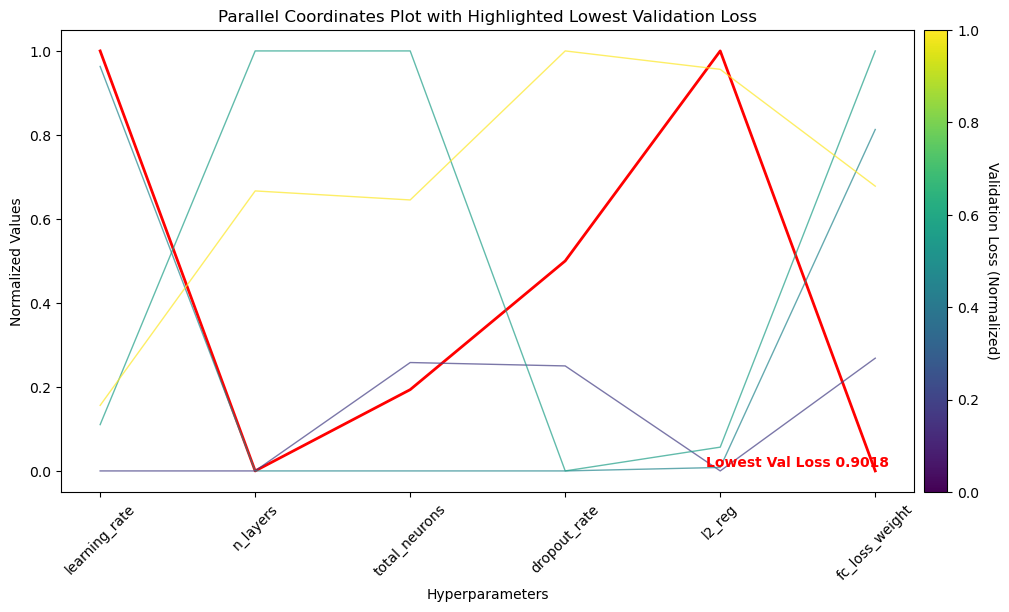

In [7]:
import matplotlib.colors as mcolors

# Updated columns for the improved hyperparameter search
# Include the NEW hyperparameters: n_layers, l2_reg, use_batchnorm
columns_to_include = ['learning_rate', 'n_layers', 'total_neurons', 'dropout_rate', 'l2_reg', 'val_loss']

# Also include fc_loss_weight if it exists (one-hot encoding)
if 'fc_loss_weight' in df.columns and df['fc_loss_weight'].notna().any():
    columns_to_include.insert(-1, 'fc_loss_weight')

filtered_df = df[columns_to_include].dropna()

# Normalize the data for better visualization
norm_df = filtered_df.copy()
norm_df[columns_to_include] = filtered_df[columns_to_include].apply(lambda x: (x - x.min()) / (x.max() - x.min() + 1e-12))

# Normalize val_loss for color mapping
norm_df['val_loss_normalized'] = (filtered_df['val_loss'] - filtered_df['val_loss'].min()) / (filtered_df['val_loss'].max() - filtered_df['val_loss'].min() + 1e-12)

# Sort by val_loss
norm_df = norm_df.sort_values(by='val_loss').reset_index(drop=True)

# Generate colors
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=norm_df['val_loss_normalized'].min(), vmax=norm_df['val_loss_normalized'].max())
colors = [cmap(norm(val)) for val in norm_df['val_loss_normalized']]

min_val_loss_index = norm_df['val_loss'].idxmin()
min_loss = round(filtered_df.loc[filtered_df['val_loss'].idxmin()]['val_loss'], 4)

# Plot parallel coordinates
fig, ax = plt.subplots(figsize=(14, 6))
plot_cols = columns_to_include[:-1]  # everything except val_loss on the x-axis
for idx, row in norm_df.iterrows():
    line = ax.plot(
        plot_cols,
        row[plot_cols],
        color='red' if idx == min_val_loss_index else colors[idx],
        alpha=1.0 if idx == min_val_loss_index else 0.7,
        linewidth=2.0 if idx == min_val_loss_index else 1.0
    )
    if idx == min_val_loss_index:
        ax.text(
            len(plot_cols) - 1.5,
            row[plot_cols].iloc[-1] + 0.01,
            f'Lowest Val Loss {min_loss}', 
            color='red', fontsize=10, fontweight='bold', ha='center'
        )

plt.subplots_adjust(right=0.85)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label('Validation Loss (Normalized)', rotation=270, labelpad=15)

ax.set_title('Parallel Coordinates Plot with Highlighted Lowest Validation Loss')
ax.set_xlabel('Hyperparameters')
ax.set_ylabel('Normalized Values')
ax.set_xticks(range(len(plot_cols)))
ax.set_xticklabels(plot_cols, rotation=45)
plt.savefig('plots/hypertuner_search_metrics/parallel_coordinates.png')
plt.show()

In [10]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Print everything as a dict
print("All best hyperparameters:")
print(json.dumps({k: (round(v, 6) if isinstance(v, float) else v) 
                  for k, v in best_hps.values.items()}, indent=2))

n_layers_best = best_hps.values.get('n_layers', 5)

print("--- Key hyperparameters ---")
print(f"  n_layers:       {n_layers_best}")
for i in range(n_layers_best):
    print(f"  neurons_{i}:      {best_hps.values.get(f'neurons_{i}')}")
print(f"  dropout_rate:   {best_hps.get('dropout_rate')}")
print(f"  l2_reg:         {best_hps.get('l2_reg')}")
print(f"  learning_rate:  {best_hps.get('learning_rate')}")
print(f"  use_batchnorm:  {best_hps.get('use_batchnorm')}")
fc_w = best_hps.values.get('fc_loss_weight')
if fc_w is not None:
    print(f"  fc_loss_weight: {fc_w}")

All best hyperparameters:
{
  "n_layers": 1,
  "neurons_0": 352,
  "neurons_1": 64,
  "neurons_2": 64,
  "dropout_rate": 0.1,
  "l2_reg": 0.008794,
  "learning_rate": 0.001194,
  "use_batchnorm": false,
  "fc_loss_weight": 0.378809,
  "neurons_3": 352
}
--- Key hyperparameters ---
  n_layers:       1
  neurons_0:      352
  dropout_rate:   0.1
  l2_reg:         0.008794126426439331
  learning_rate:  0.001193715046387881
  use_batchnorm:  False
  fc_loss_weight: 0.37880942111362037


## Additional Analysis: Impact of New Hyperparameters

BatchNorm impact on val_loss:
                   mean       std       min  count
use_batchnorm                                     
False          2.368954  1.190751  0.901791      4
True           1.419036       NaN  1.419036      1

Depth (n_layers) impact on val_loss:
              mean       std       min  count
n_layers                                     
1         1.519727  0.673947  0.901791      3
3         3.803294       NaN  3.803294      1
4         2.532378       NaN  2.532378      1



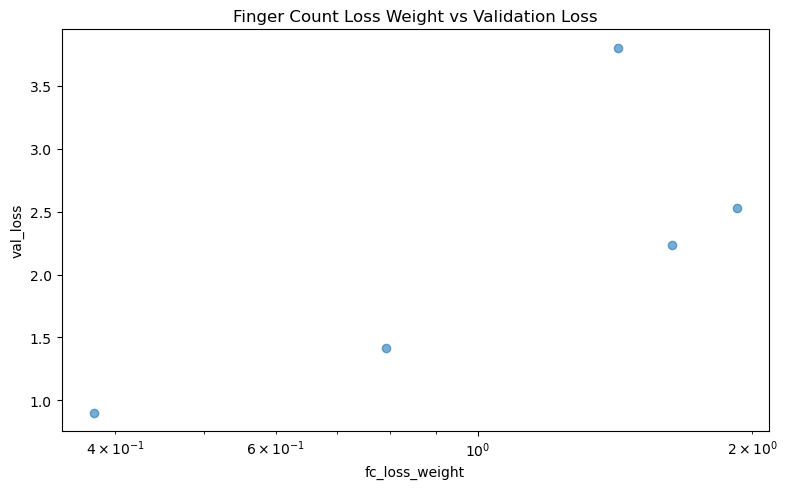

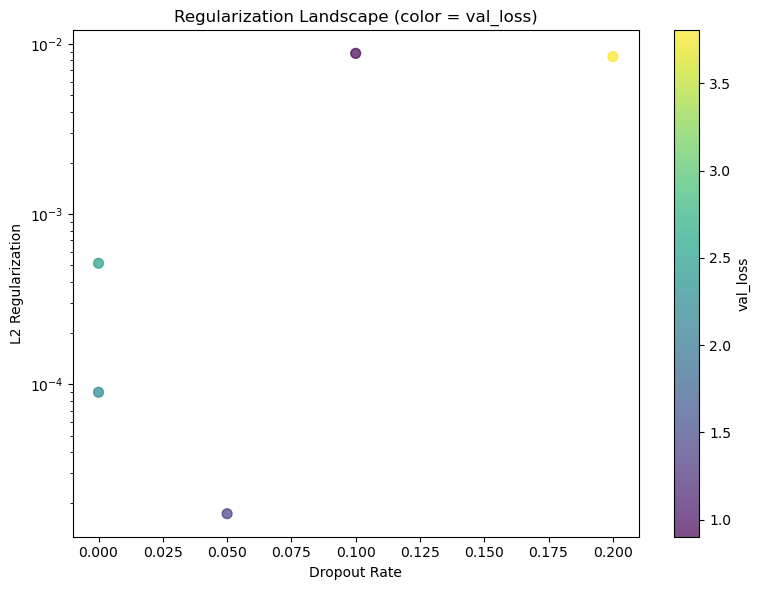

In [11]:
# BatchNorm impact
if 'use_batchnorm' in df.columns:
    bn_groups = df.groupby('use_batchnorm')['val_loss'].agg(['mean', 'std', 'min', 'count'])
    print("BatchNorm impact on val_loss:")
    print(bn_groups.to_string())
    print()

# Depth impact
if 'n_layers' in df.columns:
    depth_groups = df.groupby('n_layers')['val_loss'].agg(['mean', 'std', 'min', 'count'])
    print("Depth (n_layers) impact on val_loss:")
    print(depth_groups.to_string())
    print()

# fc_loss_weight impact (if present)
if 'fc_loss_weight' in df.columns and df['fc_loss_weight'].notna().any():
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(df['fc_loss_weight'], df['val_loss'], alpha=0.6)
    ax.set_xlabel('fc_loss_weight')
    ax.set_ylabel('val_loss')
    ax.set_title('Finger Count Loss Weight vs Validation Loss')
    ax.set_xscale('log')
    plt.tight_layout()
    plt.savefig('plots/hypertuner_search_metrics/fc_loss_weight_vs_val_loss.png')
    plt.show()

# Dropout vs L2 heatmap
if 'dropout_rate' in df.columns and 'l2_reg' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(df['dropout_rate'], df['l2_reg'], c=df['val_loss'], cmap='viridis', alpha=0.7, s=50)
    ax.set_xlabel('Dropout Rate')
    ax.set_ylabel('L2 Regularization')
    ax.set_yscale('log')
    ax.set_title('Regularization Landscape (color = val_loss)')
    plt.colorbar(sc, label='val_loss')
    plt.tight_layout()
    plt.savefig('plots/hypertuner_search_metrics/regularization_landscape.png')
    plt.show()